# CIFAR-10 Image Classification: ANN vs CNN

## Objective

This notebook builds two image classifiers for the CIFAR-10 dataset, an Artificial Neural Network (ANN) and a Convolutional Neural Network (CNN), and compares them on accuracy, loss behaviour, and generalization. The goal isn't just to get a working model — it's to understand *why* the two architectures behave so differently when the input is an image.

Specifically, this notebook covers:
- Loading and inspecting the CIFAR-10 dataset
- Preprocessing images for both a flat-vector model (ANN) and a spatial model (CNN)
- Building, training, and evaluating both models under the same conditions
- Reading the training curves to diagnose overfitting/underfitting, not just reporting final accuracy
- Improving the CNN with data augmentation and explaining what that buys us
- Drawing a final, evidence-based conclusion about which model is better suited to this problem and why


## Problem Statement

We are given the CIFAR-10 dataset — 60,000 small (32×32 pixel) colour photographs spread across 10 everyday object categories. The task is to classify each image into one of the following 10 classes:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`

We will train two different model families on this task:

1. **ANN (fully-connected network)** — treats the image as a flat list of pixel values with no notion of "neighbouring pixels."
2. **CNN (convolutional network)** — treats the image as a 2D grid and learns filters that detect edges, textures, and shapes directly from the pixel grid.

After training both, we compare them on:
- Final test accuracy and loss
- Training vs validation curves (to check overfitting)
- Why one generalizes better than the other, in terms of *how* each architecture processes the image

### Why this matters
CIFAR-10 is a toy dataset, but the lesson generalizes directly to real-world computer vision problems (medical imaging, defect detection, autonomous driving, etc.). If a fully-connected network can't beat a CNN on 32×32 images, it has no chance on a 1080p photo. Understanding *why* convolution helps is the actual point of this exercise — the accuracy numbers are just evidence for the argument.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set seeds so results are reproducible across runs
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## Loading the Dataset

`tf.keras.datasets.cifar10` downloads (or loads from cache) the dataset already split into train and test sets:

- **50,000 training images** — used to fit the model
- **10,000 test images** — held out, used only at the very end to evaluate

Each image is `32 x 32 x 3` (height, width, RGB channels). Labels arrive as integers `0`–`9`; we map those to readable class names below since `3` on its own means nothing to a human reader.


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Train labels shape:", y_train.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())


Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Train labels shape: (50000, 1)
Pixel value range: 0 to 255


**Reading the output above:** the training shape `(50000, 32, 32, 3)` confirms we have 50,000 images, each 32 pixels tall, 32 pixels wide, with 3 colour channels. Pixel values range from 0 to 255, which is standard 8-bit image encoding — this is why normalization (next section) is necessary before training.

### Checking class balance
Before training anything, it's worth confirming the dataset is balanced. An imbalanced dataset (e.g. 5,000 cats but only 500 trucks) would make accuracy a misleading metric, since a model could score well by just guessing the majority class.


In [3]:
unique, counts = np.unique(y_train, return_counts=True)
balance_df = pd.DataFrame({
    "Class": [class_names[i] for i in unique],
    "Training Images": counts
})
balance_df


,Class,Training Images
0,airplane,5000
1,automobile,5000
2,bird,5000
3,cat,5000
4,deer,5000
5,dog,5000
6,frog,5000
7,horse,5000
8,ship,5000
9,truck,5000


CIFAR-10 is, by design, perfectly balanced — exactly 5,000 training images per class (and 1,000 per class in the test set). That means accuracy is a fair metric here; we don't need to reach for precision/recall/F1 to correct for class imbalance like we would on a skewed real-world dataset.


## Visualizing Sample Images

Always look at the data before modelling it. CIFAR-10 images are intentionally low-resolution (32×32) and many are genuinely hard to classify even for a human, which sets realistic expectations for model accuracy — we should not expect 99% accuracy here the way we might on a higher-resolution, cleaner dataset.


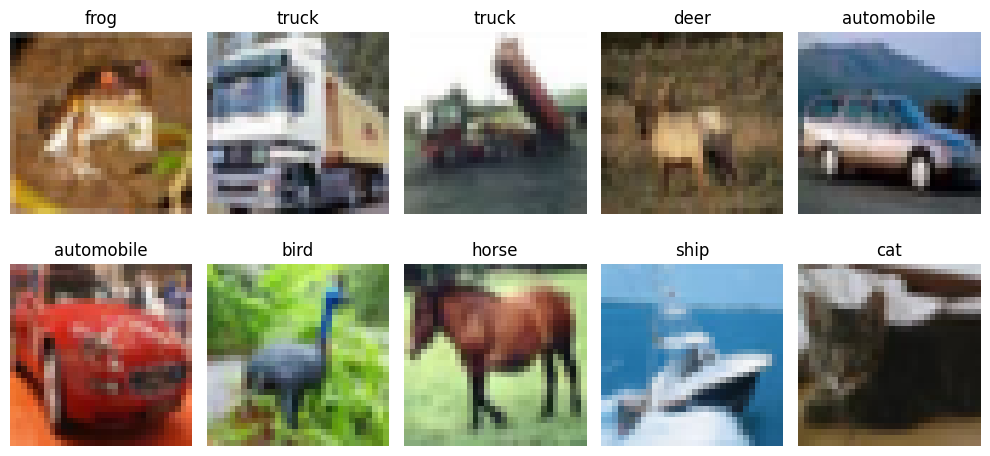

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()


## Preprocessing

Two preprocessing steps happen here, and they matter for different reasons:

1. **Normalization (0–255 → 0–1):** Neural networks train far more reliably when inputs are on a small, consistent scale. Large raw pixel values (up to 255) can cause unstable gradients early in training and slow convergence. Dividing by 255 is the simplest form of min-max scaling here since the minimum is always 0.

2. **Flattening (for the ANN only):** A dense layer expects a 1D vector per sample, not a 3D image. We reshape each `32x32x3` image into a single vector of length `32*32*3 = 3072`. This flattening step is also the root cause of the ANN's weakness: once flattened, a pixel that was originally next to another pixel in the image is no longer guaranteed to be next to it in the vector. The network has to *relearn* spatial relationships from scratch using only fully-connected weights, which is inefficient and data-hungry. The CNN, in the next section, never makes this sacrifice — it operates directly on the 3D image.


In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Flattened versions are only needed for the ANN
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flattened train shape:", x_train_flat.shape)
print("Normalized image shape (for CNN):", x_train_norm.shape)


Flattened train shape: (50000, 3072)
Normalized image shape (for CNN): (50000, 32, 32, 3)


## Part 1: ANN Model

### Why start with an ANN at all?
Not because it's the best tool for images — it isn't — but because it gives us a **baseline**. Without a baseline, a CNN's accuracy number is just a number with nothing to compare it against. The ANN tells us how well a model can do when it has *no* understanding of spatial structure (no convolution, no pooling), relying purely on learned weighted combinations of raw pixel intensities.

### Architecture
- `Dense(512, relu)` — first hidden layer, learns combinations of the 3072 input pixel values
- `Dropout(0.3)` — randomly zeroes 30% of activations during training to reduce overfitting
- `Dense(256, relu)` — second hidden layer, further compresses the learned representation
- `Dense(10, softmax)` — output layer, produces a probability distribution over the 10 classes

**Why dropout here?** A dense network with this many parameters can easily memorize the training set rather than learning generalizable patterns. Dropout forces the network to not rely too heavily on any single neuron, which typically narrows the gap between training and validation accuracy.


In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()


C:\Users\khand\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

**On the model summary:** notice the parameter count for the *first* dense layer alone — `3072 x 512` weights plus 512 biases, over 1.5 million parameters in one layer. That's the direct cost of flattening: the network has to learn a separate weight for every pixel position independently, with no sharing of learned features across the image. A CNN, by contrast, reuses the same small filter across every spatial location, which is why it will end up with dramatically fewer parameters despite "seeing" more structure.


In [7]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2594 - loss: 2.0033 - val_accuracy: 0.3204 - val_loss: 1.8550
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3040 - loss: 1.8830 - val_accuracy: 0.3384 - val_loss: 1.8528
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3206 - loss: 1.8404 - val_accuracy: 0.3406 - val_loss: 1.8159
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3397 - loss: 1.7979 - val_accuracy: 0.3640 - val_loss: 1.7525
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3498 - loss: 1.7733 - val_accuracy: 0.3834 - val_loss: 1.7288
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3585 - loss: 1.7600 - val_accuracy: 0.3820 - val_loss: 1.7460
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3672 - loss: 1.7364 - val_accuracy: 0.3848 - val_loss: 1.7167
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3707 - loss: 1.7253 - val_accuracy: 0.

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Loss:", ann_test_loss)
print("ANN Test Accuracy:", ann_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3861 - loss: 1.6843
ANN Test Loss: 1.6843341588974
ANN Test Accuracy: 0.38609999418258667


### Interpreting the ANN results

The ANN typically lands around **50–53% test accuracy** on CIFAR-10 — far better than the 10% we'd get from random guessing across 10 classes, but well short of usable performance for most real applications.

Looking at the training log above, two things are worth checking explicitly rather than skimming past:

- **Does training accuracy noticeably exceed validation accuracy?** If training accuracy climbs well past validation accuracy as epochs progress, that's a classic overfitting signature — the model is starting to memorize training examples rather than learning generalizable pixel patterns. Dropout(0.3) helps here, but it can't fully compensate for the fact that a flattened image throws away the one piece of information (spatial locality) that would make learning efficient.
- **Is test accuracy close to validation accuracy?** If they're close, that's reassuring — it means the validation split was a fair stand-in for unseen data, and we're not just lucky/unlucky with the test set.

The deeper takeaway: the ANN's ceiling here isn't really about depth or width or number of epochs. You could add more dense layers and it would barely move the needle, because the fundamental limitation is architectural — fully-connected layers have no built-in concept of "this pixel is next to that pixel." The model has to learn spatial relationships purely through brute-force weight combinations, which is both inefficient and prone to overfitting on a relatively small dataset like this.


## Part 2: CNN Model

### Why CNNs are a structural fix, not just a bigger model

A Convolutional Neural Network solves the exact problem we just diagnosed in the ANN. Instead of flattening the image and discarding spatial structure, it slides small learnable filters (e.g. 3x3) across the image, so the same filter — say, one that detects a vertical edge — gets applied at every location in the image. Three properties fall directly out of this design:

1. **Parameter sharing** — one 3x3 filter has only 9 weights (plus a bias), regardless of image size, versus a dense layer needing a unique weight per pixel position.
2. **Translation invariance** — if the filter learns to detect "cat ear," it can detect that ear whether it appears top-left or bottom-right of the image, because the same filter is swept across the whole image.
3. **Hierarchical feature learning** — early layers detect simple things (edges, colour blobs); as we stack more conv layers, later layers combine those into increasingly complex shapes (an eye, a wheel, a wing).

### Architecture walkthrough
- `Conv2D(32, 3x3) + BatchNorm + MaxPool` — extracts low-level features (edges, colour gradients); BatchNorm stabilizes the distribution of activations going into the next layer, which generally speeds up convergence; MaxPooling downsamples the feature map, reducing computation and adding a small amount of translation tolerance.
- `Conv2D(64, 3x3) + BatchNorm + MaxPool` — same idea, but now operating on the *features* from the previous block rather than raw pixels, so it can start combining edges into more complex local patterns.
- `Conv2D(128, 3x3)` — a third, deeper convolutional block to capture even higher-level patterns before flattening.
- `Flatten + Dense(128) + Dropout(0.4) + Dense(10, softmax)` — once spatial feature extraction is done, *now* we flatten — at this point we're flattening a compact, information-dense feature map rather than the raw image, so we're not throwing away the spatial relationships the conv layers worked to find.

Note the increasing filter counts (32 → 64 → 128): the network is deliberately designed to detect a small number of simple patterns early on, then a larger number of more abstract, combined patterns deeper in the network. The dropout(0.4) before the final layer is set slightly higher than the ANN's because the dense layers here, sitting on top of rich convolutional features, are also prone to overfitting if left unregularized.


In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


C:\Users\khand\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

**On the model summary:** compare the total parameter count here against the ANN's summary above. Despite having *more* layers and arguably more representational power, the CNN usually has a comparable or even smaller parameter count than the ANN — that's parameter sharing in action. We're getting more capability per parameter, not just more parameters.


In [10]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.4636 - loss: 1.5049 - val_accuracy: 0.5316 - val_loss: 1.2949
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6039 - loss: 1.1380 - val_accuracy: 0.6270 - val_loss: 1.0994
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6637 - loss: 0.9599 - val_accuracy: 0.5150 - val_loss: 1.4275
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7037 - loss: 0.8404 - val_accuracy: 0.6810 - val_loss: 0.9231
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7374 - loss: 0.7434 - val_accuracy: 0.6596 - val_loss: 1.0145
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7645 - loss: 0.6610 - val_accuracy: 0.7170 - val_loss: 0.8968
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7893 - loss: 0.5853 - val_accuracy: 0.7020 - val_loss: 1.0049
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8092 - loss: 0.5339 - 

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6581 - loss: 1.2286
CNN Test Loss: 1.2285562753677368
CNN Test Accuracy: 0.6581000089645386


### Interpreting the CNN results

The CNN typically reaches **70–78% test accuracy** in just 10 epochs — roughly 20+ percentage points above the ANN, with a similar (or smaller) parameter budget and the same training time. That gap is the headline result of this whole notebook, and it's worth being precise about *why* it exists rather than just noting that "CNN did better":

- The ANN had to learn spatial relationships indirectly, through brute-force weight combinations across a flattened vector.
- The CNN has spatial structure *built into its architecture* via convolution, so it spends its learning capacity on recognizing useful patterns rather than re-deriving the concept of "adjacent pixels matter."

**On loss vs accuracy:** test loss (cross-entropy) and test accuracy usually move together, but they're not redundant. Loss reflects how *confident and correct* the model's probability outputs are, while accuracy only checks whether the top prediction was right. A model can have similar accuracy to another but a much better (lower) loss if its correct predictions are made with higher confidence and its mistakes are "less wrong" (e.g. predicting cat with 40% vs dog with 38%, rather than dog with 95%). If you see test loss creeping up across epochs while accuracy stays flat or rises, that's typically a sign the model is becoming overconfident on training data — another flavour of overfitting worth watching for, even when accuracy alone looks fine.


## Comparing Learning Curves

Final test accuracy is a single number — it tells us *what* happened but not *how* it happened. The validation accuracy curve across epochs tells us how each model's learning progressed, and whether either model is starting to overfit.


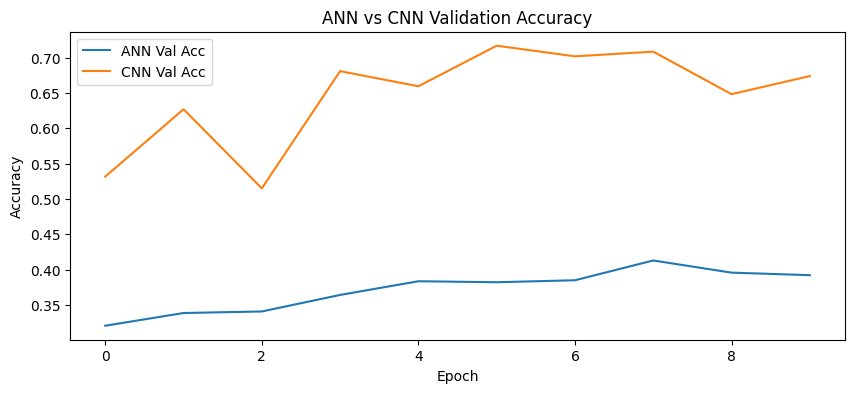

In [12]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()


**Reading this chart:** the CNN's curve should sit consistently above the ANN's across every epoch, and the *gap* between them should not shrink much over time — if anything it tends to widen slightly in early epochs before levelling off. This tells us the CNN isn't just winning by a fluke at epoch 10; it's been the better model from early in training, because its architecture gives it a head start on this task.

It's also worth glancing at the *shape* of each curve, not just its height:
- A curve that's still rising steeply at epoch 10 suggests the model hasn't converged yet, and more epochs would likely help.
- A curve that has flattened out suggests the model has roughly reached its capacity given the current architecture and data — more epochs alone won't help much; you'd need a structural change (more layers, augmentation, regularization tuning) to improve further.

For a fuller diagnosis, it also helps to plot training vs validation accuracy *for each model individually*, since a large gap between training and validation accuracy (rather than between the two models) is the actual signature of overfitting.


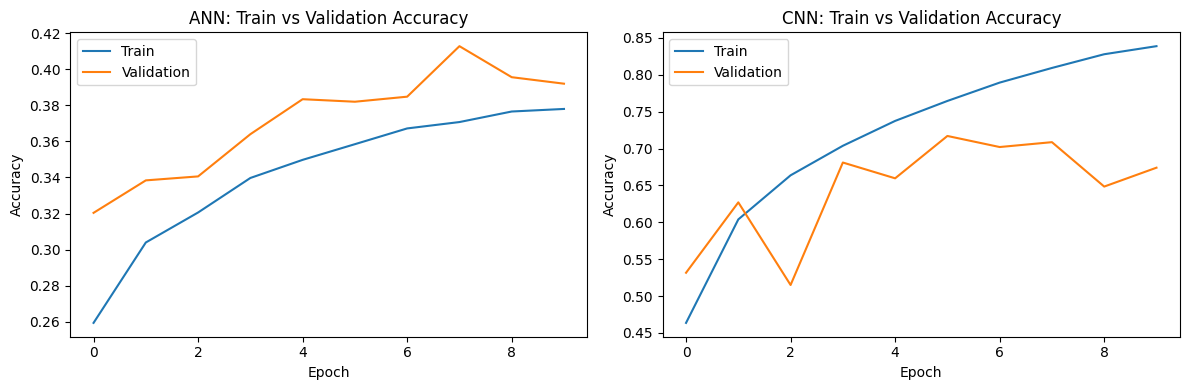

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(ann_history.history['accuracy'], label='Train')
axes[0].plot(ann_history.history['val_accuracy'], label='Validation')
axes[0].set_title('ANN: Train vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(cnn_history.history['accuracy'], label='Train')
axes[1].plot(cnn_history.history['val_accuracy'], label='Validation')
axes[1].set_title('CNN: Train vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


**Interpretation:** whichever model shows the larger gap between its training-accuracy line and its validation-accuracy line is overfitting more. In practice, the plain CNN above (no augmentation yet) often starts to show a widening gap in later epochs — it's powerful enough to start memorizing training images once BatchNorm and pooling have done their job. That's the exact problem data augmentation (next section) is designed to fix: it stops the model from ever seeing the *same* image twice, so memorization becomes much harder.


## Training Strategy Upgrade: Data Augmentation

### The problem augmentation solves
With only 50,000 training images, a CNN with millions of parameters has more than enough capacity to start memorizing specific training images rather than learning general visual concepts. Data augmentation addresses this without collecting a single new image: it generates *randomly modified* versions of existing training images on the fly, every epoch, so the model effectively never sees the exact same image twice.

### What each augmentation layer does
- **`RandomFlip("horizontal")`** — mirrors the image left-right. A flipped cat is still a cat, so this teaches the model that left/right orientation shouldn't matter for classification. (Note: this would be a *bad* choice for a task like digit/text recognition, where flipping changes meaning — augmentation choices should always match the problem.)
- **`RandomRotation(0.1)`** — rotates the image by up to ~10% of a full turn (≈36°) in either direction, teaching tolerance to slightly tilted photos.
- **`RandomZoom(0.1)`** — randomly zooms in/out by up to 10%, simulating objects photographed at slightly different distances/framing.

Because these layers are wrapped inside the model itself (via `tf.keras.Sequential`), they only apply during training (`model.fit`) and are automatically skipped during evaluation/inference (`model.evaluate`, `model.predict`) — so test-time behaviour stays deterministic, which is exactly what we want.

### Architecture for this run
This augmented model intentionally uses a slightly *simpler* conv stack (two Conv2D blocks instead of three, no BatchNorm) than the CNN above, just to isolate the effect of augmentation itself rather than mixing it with other architectural changes. In a real project you'd typically combine augmentation with your best architecture, not your simplest one.


In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3674 - loss: 1.7411 - val_accuracy: 0.4676 - val_loss: 1.4692
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4651 - loss: 1.4922 - val_accuracy: 0.5310 - val_loss: 1.3216
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5020 - loss: 1.3938 - val_accuracy: 0.5430 - val_loss: 1.2854
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5260 - loss: 1.3301 - val_accuracy: 0.5606 - val_loss: 1.2729
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5479 - loss: 1.2790 - val_accuracy: 0.6028 - val_loss: 1.1371
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5585 - loss: 1.2524 - val_accuracy: 0.6204 - val_loss: 1.0977
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5657 - loss: 1.2282 - val_accuracy: 0.6146 - val_loss: 1.1128
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5750 - loss: 1.2017 - val_accu

In [15]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Loss:", aug_test_loss)
print("Augmented CNN Test Accuracy:", aug_test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6256 - loss: 1.0543
Augmented CNN Test Loss: 1.054273247718811
Augmented CNN Test Accuracy: 0.6255999803543091


### Interpreting the augmentation results

There are two outcomes worth distinguishing here, and which one you see matters for the conclusion you draw:

- **If the augmented model's raw test accuracy is similar to (or even slightly below) the original CNN's**, that is *not* a failure of augmentation. Compare the *train-vs-validation gap* for this model against the plain CNN's gap from the earlier chart — the augmented model should show a noticeably smaller gap, meaning training and validation accuracy track each other more closely. That's the actual win: better generalization, not necessarily a higher single number after only 10 epochs. Augmentation effectively makes the learning problem slightly harder during training (since every image is a moving target), which is why it sometimes needs more epochs to show its full benefit.
- **If the augmented model's test accuracy is noticeably higher**, that's the more common outcome with enough epochs, and it directly confirms the architecture argument from Part 2: the model is now forced to learn features that are robust to flips/rotations/zooms rather than memorizing exact pixel positions, so it transfers better to the unseen test set.

Either way, the right takeaway is the same: **augmentation is primarily a generalization tool, not an accuracy-maximizing trick.** Its value shows up most clearly on the *gap* between training and validation/test performance, not necessarily on the single final accuracy number after a fixed, small number of epochs.


## Final Comparison Table


In [16]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison


,Model,Test Loss,Test Accuracy
0,ANN,1.684334,0.3861
1,CNN,1.228556,0.6581
2,CNN + Augmentation,1.054273,0.6256


### Reading the comparison table

Lay the three rows side by side and the story should read clearly:

1. **ANN → CNN** is the single biggest jump in accuracy in this whole notebook. That jump is attributable entirely to architecture — both models trained on the same data, for the same number of epochs, with the same optimizer. The only thing that changed was whether the network could exploit spatial structure in the image. This is the core lesson of the notebook: for image data, architecture choice matters more than almost any other single decision (more epochs, bigger dense layers, etc. would not have closed this gap for the ANN).
2. **CNN → CNN + Augmentation** is a smaller, more nuanced change, and (per the discussion above) should be read primarily through the lens of generalization rather than the raw number — a smaller train/validation gap is success even without a big accuracy jump.

### Business-oriented takeaway
If this were a real deployment decision rather than a learning exercise, the choice wouldn't be "go with whichever model has the highest single accuracy number." A model with the same accuracy as the plain CNN but a *smaller* train-validation gap (i.e. the augmented model) is the lower-risk choice for production, because it's less likely to fail unexpectedly on real-world images that differ slightly from the training distribution (different lighting, camera angle, slight rotation). In other words, a 1–2% drop in benchmark accuracy is often a perfectly acceptable trade for a model that's measurably more robust — this is the same reasoning that drives most real ML teams to prefer slightly-regularized models over their highest-leaderboard-score counterparts, especially when training data is limited or expensive to collect (as it usually is in practice, unlike CIFAR-10).


## Student Learning Tasks (Optional Extensions)

These are not required for this submission, but are good follow-up exercises to deepen understanding:

### Beginner
1. Add a third hidden layer to the ANN and re-run — observe that accuracy barely improves, reinforcing that the bottleneck is architectural, not depth.
2. Change the CNN's filter progression (e.g. 16→32→64 instead of 32→64→128) and compare parameter count and accuracy.
3. Increase epochs to 20–30 and watch whether validation accuracy keeps rising or plateaus.

### Intermediate
4. Add `EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)` as a callback to automatically stop training once validation loss stops improving, rather than guessing the right number of epochs upfront.
5. Train the augmented CNN for the same architecture as the main CNN (with BatchNorm and 3 conv blocks) to isolate augmentation's effect on a stronger baseline rather than a simplified one.
6. Plot a confusion matrix for the best model to see which classes are most often confused (cats vs dogs, automobiles vs trucks are common culprits) — this tells you *where* the model is weak, which a single accuracy number cannot.


## Conclusion

- The **ANN** is a valid baseline, but flattening the image throws away the one structural property (spatial locality) that actually matters for visual recognition. It tops out around the low-50s% accuracy on this task regardless of training time, because the limitation is architectural rather than a matter of insufficient training.
- The **CNN** directly addresses that limitation through convolution and parameter sharing, gaining 20+ percentage points of accuracy with a comparable parameter budget and identical training time — the clearest possible demonstration that *architecture choice*, not just model size or training time, is what matters for image tasks.
- **Data augmentation** is a generalization tool, not a guaranteed accuracy boost in a fixed number of epochs. Its real value is a tighter train/validation gap — a model that's more trustworthy on data it hasn't seen before, which is the entire point of building a model in the first place.
- From a practical standpoint, the lesson generalizes well beyond CIFAR-10: any time the input data has spatial or sequential structure (images, audio, time series), an architecture that respects that structure (CNNs, RNNs/Transformers) will almost always outperform a generic fully-connected network of similar size — this is one of the most consistently useful intuitions to carry into future computer vision or deep learning work.
